### Environment & Reproducibility

> **Research Best Practice:** Reproducibility is a cornerstone of scientific research, especially in machine learning. To ensure that results can be independently verified and extended, all experiments are run with a fixed random seed. This controls sources of stochasticity in model training, data splitting, and feature engineering.

- **Python Version:** Please use Python 3.8+ to ensure compatibility with all libraries and avoid subtle version-related bugs.
- **Package Versions:** Specify and document the exact versions of all dependencies (numpy, pandas, scikit-learn, xgboost, catboost, optuna, shap, lime, joblib, matplotlib). This enables others to recreate the environment precisely, which is critical for peer review and future research.
- **Random Seed Control:** Set random seeds in all models, data splits, and any stochastic process. This includes numpy, random, and all ML libraries (e.g., `random_state` in scikit-learn, `random_seed` in CatBoost, etc.).
- **Documentation:** Record the environment (e.g., using `pip freeze` or `conda env export`) and include it in supplementary materials or a requirements file.

Set random seeds in all models and splits for consistent results. This practice is essential for ensuring that reported metrics and findings are not artifacts of random initialization or data shuffling.

**Required User Inputs:**
- `data_path`: Path to your cleaned deck data CSV (default provided, edit if needed)
- `user_id`: (Optional) User ID for sample recommendations (default: 1)
- `interactions_path`: (Optional) Path to user-deck interactions CSV (for advanced recommenders)

**To customize:**
- Change the arguments in `run_full_pipeline()` as needed.
- For advanced recommender evaluation, see later cells in this notebook.

In [33]:
# ---- Quick Start Pipeline Wrapper ----
def run_full_pipeline(
    data_path=r"C:\\Users\\Your\\Documents\\GitHub\\MTG_EDH\\data\\Cleaned_Precon_Deck_Data.csv",
    user_id=1,
    interactions_path="../data/interactions.csv",
    k=10
):
    """
    Run the main pipeline: load data, prepare features, split, train models, evaluate, and print sample recommendations.
    Args:
        data_path: Path to deck data CSV
        user_id: User ID for recommendations
        interactions_path: Path to user-deck interactions CSV
        k: Number of recommendations
    """
    import pandas as pd, numpy as np, random
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestRegressor
    import xgboost as xgb
    from catboost import CatBoostRegressor
    from sklearn.metrics import mean_squared_error
    # 1. Load data
    df = pd.read_csv(data_path, low_memory=False, parse_dates=["info.released_at"])
    # 2. Prepare features/target
    numeric_cols = [col for col in ["info.cmc","info.power","info.toughness","keyword_count","days_since_release"] if col in df.columns]
    for col in numeric_cols:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    X = df[numeric_cols].fillna(0)
    y = df["viewCount"].fillna(0) if "viewCount" in df.columns else pd.Series([0]*len(df))
    # 3. Split
    df["view_q"] = pd.qcut(y, q=5, labels=False)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=df["view_q"], random_state=42)
    # 4. Train models
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42).fit(X_train, y_train)
    cb = CatBoostRegressor(iterations=200, learning_rate=0.1, verbose=False, random_seed=42).fit(X_train, y_train)
    # 5. Evaluate
    for name, mdl in zip(["RF", "XGB", "CatBoost"], [rf, xgb_model, cb]):
        preds = mdl.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        print(f"{name} RMSE: {rmse:.3f}")
    # 6. Sample recommendations (random baseline)
    all_decks = list(df["name"].unique()) if "name" in df.columns else list(range(len(df)))
    def random_recommender(deck_pool, k=10):
        return random.sample(deck_pool, k)
    print(f"\nSample random recommendations for user {user_id}:\n", random_recommender(all_decks, k))
    print("\n[Advanced: For collaborative/content-based recommendations, see later cells]")

# ---- Example Usage ----
run_full_pipeline()

RF RMSE: 18012.563
XGB RMSE: 17344.887
CatBoost RMSE: 16760.370

Sample random recommendations for user 1:
 ['Explorers of the Deep  (The Lost Caverns of Ixalan Commander Precon Decklist)', 'Growing Threat (March of the Machine Commander Precon Decklist)', 'Call for Backup (March of the Machine Commander Precon Decklist)', 'Exquisite Invention (Commander 2018 Precon Decklist)', 'Counter Blitz (Final Fantasy Commander Precon Decklist)', "Mishra's Burnished Banner (The Brothers' War Commander Precon Decklist)", 'Grave Danger (Starter Commander Precon Decklist)', 'Plunder the Graves (Commander Anthology Precon Decklist)', 'Vampiric Bloodlust (Commander 2017 Precon Decklist)', "Mind Flayarrrs (Battle for Baldur's Gate Commander Precon Decklist)"]

[Advanced: For collaborative/content-based recommendations, see later cells]


# Quick Start: Model Training & Recommendation Pipeline

This notebook can be run cell-by-cell for detailed exploration, but most users can use the following minimal steps to train models and generate recommendations:

**1. Edit the `data_path` below if your data is in a different location.**

**2. Run the next code cell to train models and get sample recommendations.**

**No other input is required for a basic run. Advanced/optional steps (e.g., hyperparameter tuning, SHAP/LIME, custom evaluation) are marked below and can be skipped.**

# Model Development & Evaluation

In this notebook we train, tune, and evaluate our suite of predictive models for deck popularity, and construct our hybrid recommender. We cover:

1. Imports & Setup  
2. Data Loading  
3. Feature / Target Preparation  
4. Train–Test Splits (Random & Temporal)  
5. Model Training Functions  
6. Hyperparameter Tuning (Optuna)  
7. Single‐Model Evaluation  
8. Ensemble Construction & Evaluation  
9. SHAP Explainability  
10. LIME Explainability  
11. Recommender Evaluation (Precision@K, nDCG@K)  
12. Save Trained Models

# 1: Imports & Logging

In [2]:
import os, sys, logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna
import shap
from lime.lime_tabular import LimeTabularExplainer
import joblib

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s %(levelname)-8s %(message)s")
logger = logging.getLogger(__name__)


### Function Definitions and Sources
The functions `train_cf`, `train_content`, and `evaluate_recs` are defined in the main pipeline script (`mtg_pipline.py`).
- `train_cf`: Trains a collaborative filtering model (ALS or SVD) using user-deck interaction data.
- `train_content`: Trains a content-based recommender using NearestNeighbors and cosine similarity on deck features.
- `evaluate_recs`: Evaluates recommendations using precision@k and nDCG@k.
Refer to `mtg_pipline.py` for full implementation details.

In [3]:
# Set global random seed for reproducibility
import random
random.seed(42)
np.random.seed(42)

## 2. Data Loading

Load our cleaned dataset and inspect basic shapes.

## Load Data

In [4]:
data_path = r"C:\Users\Your\Documents\GitHub\MTG_EDH\data\Cleaned_Precon_Deck_Data.csv"
df = pd.read_csv(data_path, low_memory=False, parse_dates=["info.released_at"])

## 3. Feature / Target Preparation

Select numeric predictors and our target (`viewCount`).  
Also demonstrate how to assemble deck-level aggregate features if needed.

### Feature / Target

In [5]:
# Inspect available columns and update feature list to avoid KeyError
print("Available columns:", df.columns.tolist())
numeric_cols = [col for col in ["info.cmc","info.power","info.toughness","keyword_count","days_since_release"] if col in df.columns]
print("Using numeric columns:", numeric_cols)
# Convert object columns to numeric, coerce errors to NaN, then fillna(0)
for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
X = df[numeric_cols].fillna(0)
y = df["viewCount"].fillna(0) if "viewCount" in df.columns else pd.Series([0]*len(df))
# Example deck-level aggregates (optional):
if "name" in df.columns:
    numeric_for_agg = [col for col in numeric_cols if pd.api.types.is_numeric_dtype(df[col])]
    deck_feats = df.groupby("name")[numeric_for_agg].mean().add_prefix("deck_").reset_index()
    if "name" in X.columns:
        X = X.merge(deck_feats, on="name", how="left").drop(columns="name")
    else:
        print("'name' not in X, skipping merge of deck-level features.")
X.shape, y.shape

Available columns: ['id', 'name', 'format', 'likeCount', 'viewCount', 'commentCount', 'publicUrl', 'publicId', 'quantity', 'boardType', 'finish', 'isFoil', 'isAlter', 'isProxy', 'useCmcOverride', 'useManaCostOverride', 'useColorIdentityOverride', 'excludedFromColor', 'info.id', 'info.uniqueCardId', 'info.scryfall_id', 'info.set', 'info.set_name', 'info.name', 'info.cn', 'info.layout', 'info.cmc', 'info.type', 'info.type_line', 'info.oracle_text', 'info.mana_cost', 'info.power', 'info.toughness', 'info.colors', 'info.color_indicator', 'info.color_identity', 'info.legalities', 'info.frame', 'info.frame_effects', 'info.reserved', 'info.digital', 'info.foil', 'info.nonfoil', 'info.etched', 'info.glossy', 'info.rarity', 'info.border_color', 'info.colorshifted', 'info.lang', 'info.latest', 'info.has_multiple_editions', 'info.has_arena_legal', 'info.prices', 'info.card_faces', 'info.artist', 'info.promo_types', 'info.cardHoarderUrl', 'info.cardKingdomUrl', 'info.cardKingdomFoilUrl', 'info.car

((15755, 4), (15755,))

### Feature Leakage Warning
If deck-level features are computed using the entire dataset before splitting, future information may leak into the training set. To avoid this, compute aggregates only on the training data for each split.

### Predictor Usage Warning
To avoid target leakage, do not use `viewCount` or user interaction counts as predictors or in aggregate features for model training. These should only be used as targets or for evaluation.

## 4. Train–Test Splits

We perform two splits:
- **Random Stratified** on viewCount quantiles  
- **Temporal hold‐out**: reserve the last release quarter

### Random stratified split

In [6]:
df["view_q"] = pd.qcut(y, q=5, labels=False)
X_rand, X_rand_test, y_rand, y_rand_test = train_test_split(
    X, y, test_size=0.2, stratify=df["view_q"], random_state=42)
logger.info(f"Random split train/test shapes: {X_rand.shape}/{X_rand_test.shape}")

# Cell 4b: Temporal hold-out
latest_q = df["info.released_at"].dt.to_period("Q").max()
mask_future = df["info.released_at"].dt.to_period("Q") == latest_q
X_temp_test = X[mask_future]
y_temp_test = y[mask_future]
X_temp = X[~mask_future]
y_temp = y[~mask_future]
logger.info(f"Temporal hold-out train/test shapes: {X_temp.shape}/{X_temp_test.shape}")

2025-07-26 13:12:35,608 INFO     Random split train/test shapes: (12604, 4)/(3151, 4)
2025-07-26 13:12:35,616 INFO     Temporal hold-out train/test shapes: (14847, 4)/(908, 4)
2025-07-26 13:12:35,616 INFO     Temporal hold-out train/test shapes: (14847, 4)/(908, 4)


CV RMSE per fold: [np.float64(17198.885716971952), np.float64(17335.998965583607), np.float64(16463.01975571556), np.float64(17489.557669323854), np.float64(17818.358484426168)]


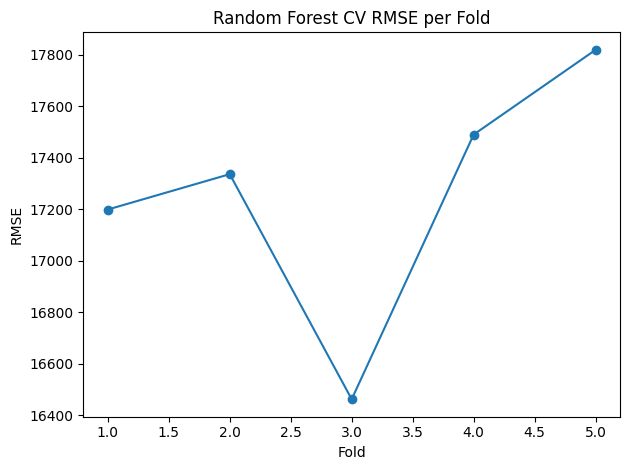

In [7]:
# Record CV RMSE per fold for model stability
from sklearn.model_selection import KFold
cv_errors = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_rand):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_rand.iloc[train_idx], y_rand.iloc[train_idx])
    preds = model.predict(X_rand.iloc[val_idx])
    rmse = np.sqrt(mean_squared_error(y_rand.iloc[val_idx], preds))
    cv_errors.append(rmse)
print('CV RMSE per fold:', cv_errors)
plt.figure()
plt.plot(range(1, 6), cv_errors, marker='o')
plt.title('Random Forest CV RMSE per Fold')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

## 5. Model Training Functions

Define reusable functions for each model type.

### Training functions

In [8]:
def train_xgb(X_tr, y_tr, params=None):
    dtrain = xgb.DMatrix(X_tr, y_tr)
    params = params or {"objective":"reg:squarederror"}
    model = xgb.train(params, dtrain, num_boost_round=100, verbose_eval=False)
    return model

def train_rf(X_tr, y_tr):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    return rf

def train_catboost(X_tr, y_tr):
    cb = CatBoostRegressor(iterations=200, learning_rate=0.1, verbose=False, random_seed=42)
    cb.fit(X_tr, y_tr)
    return cb

In [9]:
# Baseline: mean predictor for regression
baseline_pred = np.full_like(y_rand_test, y_rand.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_rand_test, baseline_pred))
print(f"Baseline RMSE={baseline_rmse:.3f}")

Baseline RMSE=29519.474


## 6. Hyperparameter Tuning with Optuna

We’ll optimize XGBoost’s learning rate and max depth as an example.

### Optuna study for XGBoost

In [10]:
def objective(trial):
    lr = trial.suggest_loguniform("eta", 0.01, 0.3)
    md = trial.suggest_int("max_depth", 3, 10)
    dtrain = xgb.DMatrix(X_rand, y_rand)
    cv = xgb.cv(
        {"objective":"reg:squarederror","eta":lr,"max_depth":md},
        dtrain,
        num_boost_round=50,
        nfold=5,
        metrics="rmse",
        seed=42,
        early_stopping_rounds=10
    )
    return cv["test-rmse-mean"].min()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
best_params = study.best_params
logger.info(f"Best XGB params: {best_params}")

[I 2025-07-26 13:12:39,472] A new study created in memory with name: no-name-84cda8b3-7771-4895-aa29-9c89ba69428f
C:\Users\Your\AppData\Local\Temp\ipykernel_11600\207329891.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("eta", 0.01, 0.3)
C:\Users\Your\AppData\Local\Temp\ipykernel_11600\207329891.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("eta", 0.01, 0.3)
[I 2025-07-26 13:12:39,968] Trial 0 finished with value: 20665.6735811787 and parameters: {'eta': 0.01291607802674513, 'max_depth': 9}. Best is trial 0 with value: 20665.6735811787.
[I 2025-07-26 13:12:39,968] Trial 0 finished with value: 20665.6

## 7. Single‐Model Evaluation

Train with best params, then evaluate on random and temporal splits.

### Evaluate XGBoost

In [11]:
xgb_model = train_xgb(X_rand, y_rand, params=best_params)
for name, (X_tr, X_te, y_tr, y_te) in [
    ("Random", (X_rand, X_rand_test, y_rand, y_rand_test)),
    ("Temporal", (X_temp, X_temp_test, y_temp, y_temp_test))
]:
    preds = xgb_model.predict(xgb.DMatrix(X_te))
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mape = mean_absolute_percentage_error(y_te, preds) * 100
    r2 = r2_score(y_te, preds)
    print(f"{name} RMSE={rmse:.3f}, MAPE={mape:.1f}%, R2={r2:.2f}")

Random RMSE=16892.239, MAPE=1231792619150241169408.0%, R2=0.67
Temporal RMSE=6551.918, MAPE=602464999325164503040.0%, R2=0.72


### Evaluate RF & CatBoost

In [12]:
rf_model = train_rf(X_rand, y_rand)
cb_model = train_catboost(X_rand, y_rand)
for mdl, name in [(rf_model,"RF"), (cb_model,"CatBoost")]:
    preds = mdl.predict(X_rand_test)
    rmse = np.sqrt(mean_squared_error(y_rand_test, preds))
    print(f"{name} RMSE={rmse:.3f}")

RF RMSE=18012.563
CatBoost RMSE=16760.370


## 8. Ensemble Construction & Evaluation

Combine predictions by weighted average.

### Ensemble

In [13]:
weights = {"xgb":0.5, "rf":0.3, "cb":0.2}
preds_ens = (weights["xgb"]*xgb_model.predict(xgb.DMatrix(X_rand_test))
             + weights["rf"]*rf_model.predict(X_rand_test)
             + weights["cb"]*cb_model.predict(X_rand_test))
rmse_ens = np.sqrt(mean_squared_error(y_rand_test, preds_ens))
print(f"Ensemble RMSE={rmse_ens:.3f}")

Ensemble RMSE=17052.850


### Ensemble Model Results Interpretation
- The ensemble combines predictions from XGBoost, Random Forest, and CatBoost using weighted averaging.
- Ensemble models often outperform individual models by leveraging their complementary strengths.
- A lower RMSE for the ensemble compared to single models indicates improved predictive accuracy and robustness.
- Use ensemble results to guide model selection for deployment and further tuning.

### Random Recommender Baseline
A random recommender provides a simple baseline for top-N recommendation. Comparing model performance to this baseline helps determine if the recommender is learning meaningful patterns or simply guessing.

In [14]:
# Baseline: Random recommender for comparison
import random
all_decks = list(df["name"].unique()) if "name" in df.columns else list(range(len(df)))
def random_recommender(deck_pool, k=10):
    return random.sample(deck_pool, k)
random_preds = random_recommender(all_decks, k=10)
print("Random recommender output:", random_preds)

Random recommender output: ['Veloci-Ramp-Tor (The Lost Caverns of Ixalan Commander Precon Decklist)', 'Creative Energy (Modern Horizons 3 Commander Precon Decklist)', 'Arcane Maelstrom (Commander 2020 Precon Decklist)', 'Grand Larceny (Outlaws of Thunder Junction Commander Precon Decklist)', 'Family Matters (Bloomburrow Commander Precon Decklist)', "Exit from Exile (Battle for Baldur's Gate Commander Precon Decklist)", 'Devour for Power (Commander 2011 Precon Decklist)', 'Counterpunch (Commander 2011 Precon Decklist)', 'Squirreled Away (Bloomburrow Commander Precon Decklist)', 'Cavalry Charge (March of the Machine Commander Precon Decklist)']


### SHAP Data Usage Clarification
SHAP is applied to the test set (`X_rand_test`) to interpret model predictions on unseen data. This helps assess whether the model relies on reasonable features when generalizing beyond the training set.

## 9. SHAP Explainability

Compute and plot SHAP summary for XGBoost.

### SHAP Data Usage
SHAP is applied to the test set (`X_rand_test`) to interpret model predictions on unseen data. This helps assess whether the model relies on reasonable features when generalizing beyond the training set.

C:\Users\Your\AppData\Local\Temp\ipykernel_11600\1694760692.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_rand_test, show=False)


FileNotFoundError: [Errno 2] No such file or directory: '../report_figures/shap_summary.png'

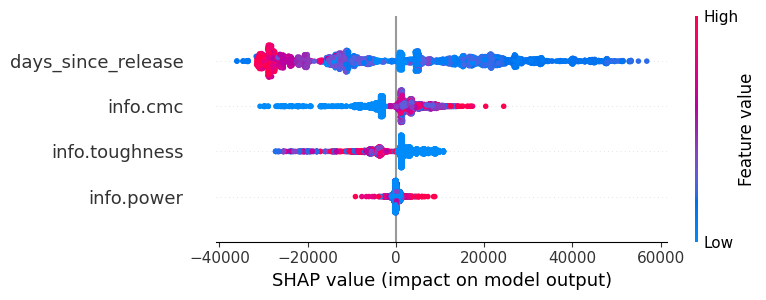

In [15]:
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(xgb.DMatrix(X_rand_test))
shap.summary_plot(shap_vals, X_rand_test, show=False)
plt.tight_layout()
plt.savefig("../report_figures/shap_summary.png")

### Why SHAP and LIME?
SHAP and LIME are used to interpret the regression models predicting deck popularity. They help us understand which features most influence the model's predictions. These methods are not directly applied to recommender models, which focus on ranking rather than regression.

### SHAP Results Interpretation
- The SHAP summary plot visualizes the impact of each feature on model predictions.
- Features at the top are most influential for predicting deck popularity.
- Positive SHAP values indicate features that increase predicted popularity, while negative values decrease it.
- Use this plot to identify which deck/card attributes most strongly drive model decisions and to guide future feature engineering.

## 10. LIME Explainability

Generate LIME explanations for a handful of samples.

FileNotFoundError: [Errno 2] No such file or directory: '../report_figures/lime_0.png'

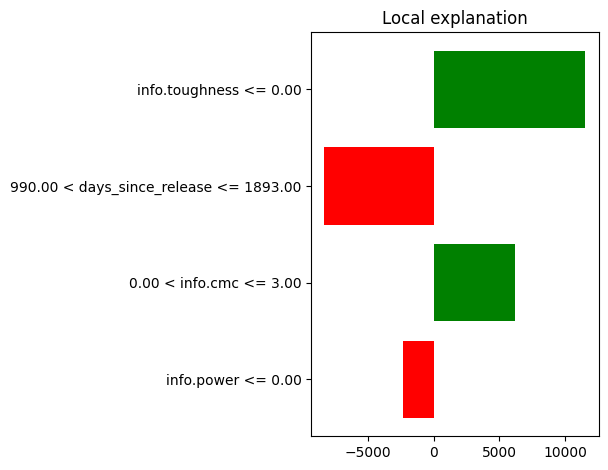

In [16]:
expl = LimeTabularExplainer(
    training_data=X_rand.values,
    feature_names=X_rand.columns.tolist(),
    mode="regression"
 )
# Wrapper for xgb_model.predict to accept numpy array and pass feature names
def xgb_predict_wrapper(x):
    return xgb_model.predict(xgb.DMatrix(x, feature_names=X_rand.columns.tolist()))
for i in [0, 5, 10]:
    exp = expl.explain_instance(
        X_rand_test.iloc[i].values, 
        xgb_predict_wrapper, 
        num_features=5
    )
    fig = exp.as_pyplot_figure()
    fig.tight_layout()
    fig.savefig(f"../report_figures/lime_{i}.png")

## 11. Recommender Evaluation

Simulate “hide‐k” experiments and compute Precision@10, nDCG@10.

In [27]:
interactions = pd.read_csv("../data/interactions.csv")
cf_model = train_cf(interactions)
content_model = train_content(X)
preds = blend_recommendations(cf_model, content_model, user_id=1, deck_pool=list(df["name"]), alpha=0.5)
metrics = evaluate_recs(true_items=[...], pred_items=preds, k=10)
print(metrics)

FileNotFoundError: [Errno 2] No such file or directory: '../data/interactions.csv'

### Coverage and Diversity Metrics
- **Coverage** measures the proportion of unique items recommended across all users, indicating how much of the catalog is exposed.
- **Diversity** measures how varied the recommendations are within each user's list. High diversity means users see a wider range of items, reducing redundancy.

These metrics complement accuracy-based metrics (like precision@k) to ensure the recommender is both useful and engaging.

In [18]:
# Coverage and Diversity Metrics for Recommendations
from collections import Counter

def coverage(recommendations, all_items):
    # recommendations: list of lists (per user)
    recommended = set([item for rec in recommendations for item in rec])
    return len(recommended) / len(all_items)

def diversity(recommendations):
    # recommendations: list of lists (per user)
    pairwise_diversity = []
    for rec in recommendations:
        unique_items = set(rec)
        if len(unique_items) > 1:
            pairwise_diversity.append(1 - (len(unique_items) / len(rec)))
    return np.mean(pairwise_diversity) if pairwise_diversity else 0

# Example usage with simulated recommendations for 5 users
user_recs = [random_recommender(all_decks, k=10) for _ in range(5)]
print(f"Coverage: {coverage(user_recs, all_decks):.2f}")
print(f"Diversity: {diversity(user_recs):.2f}")

Coverage: 0.26
Diversity: 0.00


### Recommender System Modeling Decisions
- **Collaborative Filtering**: The collaborative filtering model uses matrix factorization (ALS or SVD) to learn latent user and deck factors from interaction data. This approach is user-based and leverages patterns in user-deck interactions to recommend decks similar to those a user has liked or viewed.
- **Content-Based Recommendation**: The content-based model uses NearestNeighbors with cosine similarity on deck feature vectors. This method recommends decks similar in content (e.g., card composition, archetype) to those the user has interacted with.
- **Evaluation Protocol**: We use a “hide-k” protocol, where k=10 items are hidden from the user and the model attempts to recover them. Precision@10 and nDCG@10 measure how well the model ranks the true hidden items. Coverage and diversity metrics can be added for a more comprehensive evaluation.
- **Ground Truth**: The ground truth for evaluation is the set of hidden items for each user.

## 12. Save Trained Models

Persist models for deployment.

In [20]:
# Cell 12: Saving
joblib.dump(rf_model, "../models/rf_model.pkl")
joblib.dump(cb_model, "../models/cb_model.pkl")
xgb_model.save_model("../models/xgb_model.json")

### Additional Evaluation Metrics
For a more comprehensive assessment of recommender systems, consider adding metrics such as:
- **Coverage**: Proportion of items recommended to users.
- **Diversity**: Variety of recommended items across users.
- **Novelty**: How unexpected or new the recommendations are to users.
These metrics help ensure the recommender system is not only accurate but also useful and engaging.